In [1]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
import json
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [2]:
import utils.config as config
importlib.reload(config)
import utils.common as common
importlib.reload(common)
import utils.conduits as conduits
importlib.reload(conduits)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *
import scripts.openkarst.run_openkarst as ok
import utils.openkarst_network
importlib.reload(utils.openkarst_network)
importlib.reload(ok)
import utils.linear_reservoir as lr
importlib.reload(lr)


<module 'utils.linear_reservoir' from 'c:\\Users\\huan1428\\Documents\\karst\\UMNBearSpring\\src\\utils\\linear_reservoir.py'>

In [3]:
def get_outlet_Q(Q, outflow_node_ids, edges):
    outlets ={}
    for node in outflow_node_ids:
        edges_loc = edges[(edges.to_id == node) | (edges.from_id == node)].index
        outlet_Q = 0
        for edge in edges_loc:
            outlet_Q += Q[:, edge-1]
        outlets[node] = outlet_Q
    return outlets
def get_transient_results(results_dir,network_dir):
    out = np.load(results_dir)
    network = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv')
    Q = out['Q']
    y = out['y']
    t = out['t']
    spring = get_outlet_Q(Q, network.outlets, network.edges)
    return Q, y, t, spring

# Load Network

In [144]:
network_name = "single_conduit_vert_tort"
nodes = 'nodes.csv'
network_dir = f'conduit_geometry_test/networks/{network_name}'
network = ok.load_network_data(f'{network_dir}/{nodes}', f'{network_dir}/edges.csv', debug= True)
network.extract_diffuse_inlets()
network.conduit_lengths()
fig = network.plot_3D_network(node_color = 'type', show_nodes = False)
fig.update_layout(
    scene=dict(
        xaxis=dict(showticklabels=False, title=''),
        yaxis=dict(showticklabels=False, title=''),
        zaxis=dict(showticklabels=False, title=''),
    )
)
fig.update_traces(
    line=dict(width=10),
    selector=dict(type='scatter3d', mode='lines')
)
fig.update_layout(
    scene_camera=dict(
        eye=dict(x=1.5, y=1.5, z=0.5),   # camera position
        up=dict(x=0, y=0, z=1),           # which direction is "up"
        center=dict(x=0, y=0, z=0)        # point the camera looks at
    )
)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178]


## Diameter Distribution

In [52]:
def generate_diameter_dist(nodes, mode = 'gauss', sigma = 0.5, mean= 3, std=1.5, min_d=0.1, max_d = 5):
    if mode == 'gauss':

        D = np.random.normal(loc=mean, scale=std, size=len(nodes))
    elif mode == 'log':
        D = np.random.lognormal(mean=np.log(mean), sigma=sigma, size=len(nodes))
    # prevent diameters out of range
    D = np.maximum(D, min_d)
    D = np.minimum(D, max_d)
    
    nodes['d'] = D
    
    return nodes

In [64]:
random_d = generate_diameter_dist(network.nodes, mode = 'log')
plot_3D_network(random_d, network.edges, node_color= "d")

In [66]:
network.nodes.to_csv(f"conduit_geometry_test/networks/{network_name}/nodes_gaussian_5.csv")

In [173]:
network_names = ['pykasso_n58', 'straight_conduit_n62', 'branching_straight_network', 'single_conduit_vert_tort'
]
for network_name in network_names:
    nodes = 'nodes.csv'
    network_dir = f'conduit_geometry_test/networks/{network_name}'
    network = ok.load_network_data(f'{network_dir}/{nodes}', f'{network_dir}/edges.csv', debug= True)
    network.update_diameters(0.1)
    network.plot_3D_network(node_color = 'd')
    network.nodes.to_csv(f"conduit_geometry_test/networks/{network_name}/nodes_0.1m.csv")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178]


# Load and Write Recharge

In [67]:
#just a box injection for 1 day

baseflow = 0.02  #m3/s
peakflow = baseflow * 10
duration = 24 * 3600 # seconds
dt = 3600 #seconds
t = np.arange(0, 24*20*3600, dt) # in seconds
def gaussian_recharge(t, peak, center, duration):
    """
    t        : time array
    peak    : max recharge value
    center  : time of peak
    duration: FWHM (event duration)
    """

    sigma = duration / 2.355

    return peak * np.exp(-(t-center)**2 / (2*sigma**2))

gauss_R  = (gaussian_recharge(t, peakflow - baseflow, 24*10*3600, duration) + baseflow) * 86400 # m3/d


<Axes: >

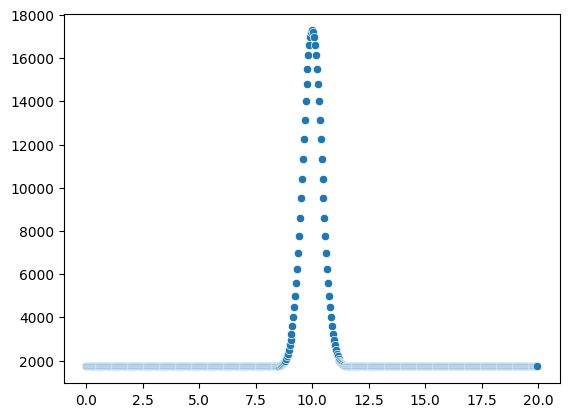

In [59]:
sns.scatterplot(y = gauss_R, x = t/86400)

In [70]:
A = 4629284 #springshed area 
n =.01 #effective porosity
d = 10 # m 
V_l = A * d * n#m^3
S_max = .3 #m
S_0 = 0.3
k = 1 #1 / d 
eta = 0.3
alpha_l = 0.1 #1 /d 
alpha_h = 0.5 #1 /d 

In [71]:
n_days = 100
# steady_state_R = np.ones(n_days) * baseflow / A * 86400 # m / d 
steady_state_R = np.ones(n_days) * baseflow * 86400 # m3 / d
steady_state_t = np.arange(0, n_days)

In [178]:
ss_R_df = pd.DataFrame({'R [m3/d]' : steady_state_R, 'T [d]' : steady_state_t})
ss_R_df.to_csv('conduit_geometry_test/input_data/baseflow_high_eta.csv', index = False)

In [72]:
ss = lr.linear_reservoir_model(steady_state_R * (1-eta), steady_state_R * eta, steady_state_t, alpha_l = alpha_l, alpha_h = alpha_h, V_l0 = 0, dt_unit = 'D')
# ss = lr.full_model(steady_state_R , np.zeros(n_days), steady_state_t/86400, A = A, eta = eta, V_l = V_l, S_max = S_max, S_0 = S_0, k = k, n_l = eta, alpha_l = alpha_l, alpha_h = alpha_h, dt_unit = 'D')

No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time object

<Axes: xlabel='date', ylabel='Q_l [V/T]'>

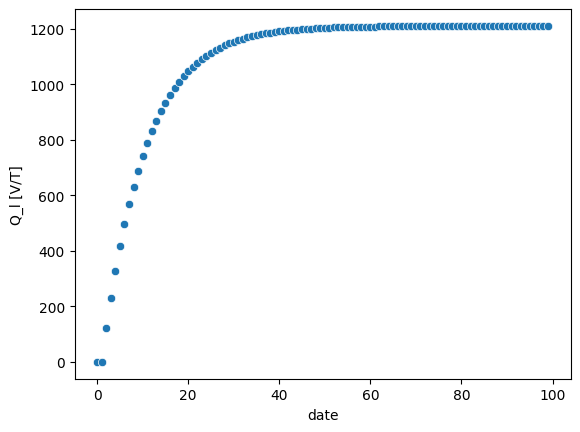

In [73]:
sns.scatterplot(ss, x = 'date', y = 'Q_l [V/T]')


In [74]:
V_l0 = ss['V_l [V]'].iloc[-1] #initial V_l 
pulse = lr.linear_reservoir_model(gauss_R * (1-eta), gauss_R * eta, t / 86400, alpha_l = alpha_l, alpha_h = alpha_h, V_l0 = V_l0, dt_unit = 'D')


No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time object

In [55]:
pulse = pd.read_csv("conduit_geometry_test/input_data/gaussian_pulse_high_eta.csv")

In [14]:
pulse['dV'] = (pulse['V_l [V]'] + pulse['V_h [V]']).diff()
pulse['dV_expected'] = (pulse['R_l [V/T]'] + pulse['R_h [V/T]'] - pulse['Q_h [V/T]']) * pulse['date'].diff()
pulse['dV_error'] = pulse['dV'] - pulse['dV_expected']
pulse['dV_error_rel'] = pulse.dV_error/pulse.dV_expected

Text(0.5, 1.0, 'Linear reservoir recharge partitioning')

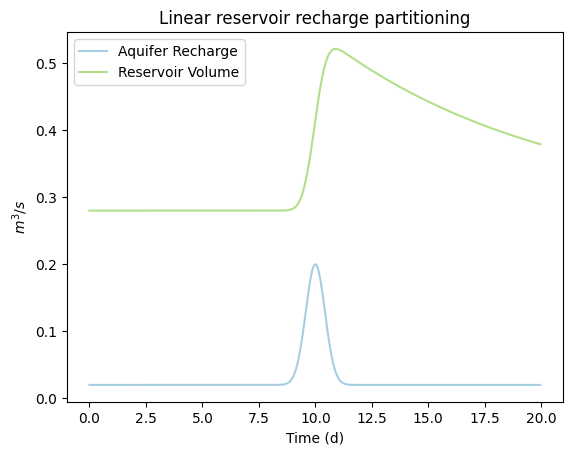

In [107]:
colors = {
    'precip':  '#A6CEE3',   # pastel blue
    'R_L':     '#FDBF6F',   # pastel orange
    'R_H':     '#B2DF8A',   # pastel green
    'Q_L':     '#FB9A99',   # pastel coral/red
    'Q_H':     '#CAB2D6',   # pastel purple
    'modeled': '#80CDC1',   # pastel teal
    'observed':'#5DA5DA'    # pastel navy
}

sns.lineplot(x =pulse.date, y =  pulse['R_l [V/T]']/86400 + pulse['R_h [V/T]']/86400, color = colors['precip'], label = 'Aquifer Recharge')

sns.lineplot(pulse, x = 'date', y = pulse['V_l [V]']/86400 +pulse['V_l [V]']/86400 , label = 'Reservoir Volume', color = colors['R_H'])
# sns.lineplot(pulse, x = 'date', y = pulse['Q_l [V/T]']/86400, label = 'Diffuse Conduit Recharge', color = colors['Q_L'])

# sns.lineplot(x = , y =, label = "Aquifer Recharge")
plt.xlabel("Time (d)")
plt.ylabel(r"$m^3/s$")
plt.title("Linear reservoir recharge partitioning")
# sns.lineplot(ss, x = 'date', y = 'R_h [L/T]')

Text(0, 0.5, '$m^3/s$')

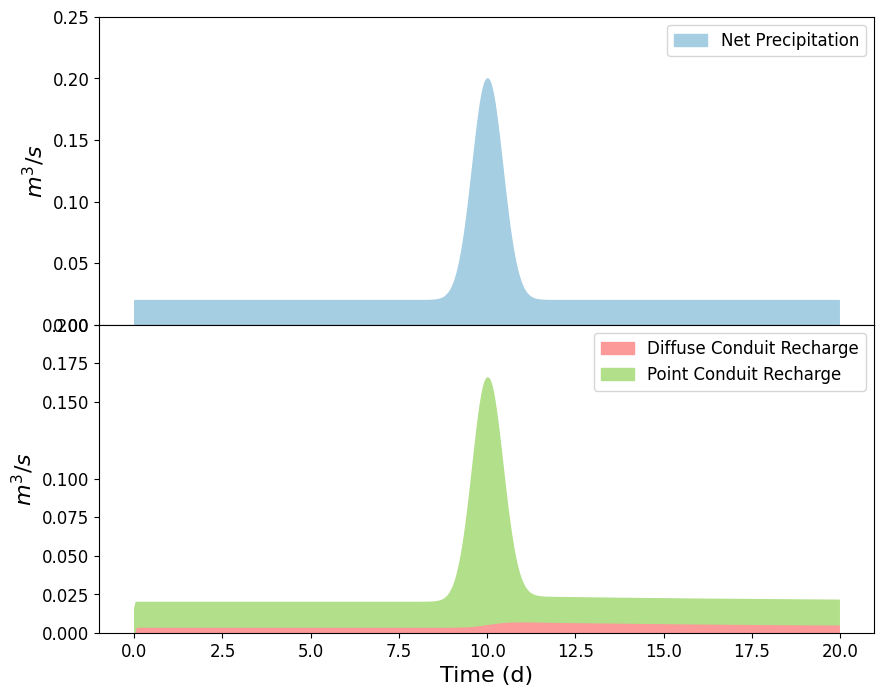

In [59]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 14            # main text size
plt.rcParams['axes.labelsize'] = 16       # axis labels
plt.rcParams['axes.titlesize'] = 18       # title
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Keep text editable in SVG for Inkscape
plt.rcParams['svg.fonttype'] = 'none'

colors = {
    'precip':  '#A6CEE3',   # pastel blue
    'R_L':     '#FDBF6F',   # pastel orange
    'R_H':     '#B2DF8A',   # pastel green
    'Q_L':     '#FB9A99',   # pastel coral/red
    'Q_H':     '#CAB2D6',   # pastel purple
    'modeled': '#80CDC1',   # pastel teal
    'observed':'#5DA5DA'    # pastel navy
}
fig, ax = plt.subplots(2,1, figsize = (10,8), sharex=True, gridspec_kw={'hspace': 0.0})

ax[0].fill_between(x =pulse.date, y1 =  pulse['R_l [V/T]']/86400 + pulse['R_h [V/T]']/86400, color = colors['precip'], label = 'Net Precipitation')
ax[0].set_ylabel(r"$m^3/s$")
ax[0].set_ylim(0,0.25)
ax[0].legend()
# ax[0].set_title("Net Precipitation")
ax[1].yaxis.get_major_ticks()[-1].set_visible(False)   # hide top tick of bottom subplot

ax[1].fill_between(pulse.date, y1 = pulse['Q_l [V/T]']/86400, label = 'Diffuse Conduit Recharge', color = colors['Q_L'])

ax[1].fill_between(pulse.date, y1 = pulse['R_h [V/T]']/86400 + pulse['Q_l [V/T]']/86400, y2 = pulse['Q_l [V/T]']/86400, label = 'Point Conduit Recharge', color = colors['R_H'])
ax[1].legend()
ax[1].set_ylim(0,0.2)
# sns.lineplot(x = , y =, label = "Aquifer Recharge")
plt.xlabel("Time (d)")
plt.ylabel(r"$m^3/s$")
# ax[1].set_title("Conduit Recharge")
# sns.lineplot(ss, x = 'date', y = 'R_h [L/T]')

In [158]:
pulse.to_csv('conduit_geometry_test/input_data/gaussian_pulse_high_eta.csv', index = False)

In [14]:
def write_recharge(network, R_l=None, R_h=None, t_l=None, t_h=None):
    R = {}
    if R_l is not None: 
        if t_l is None:
             return ValueError("Time is None")
        n_diffuse = len(network.diffuse_inlets)
        R_l_per_inlet = R_l / n_diffuse 
        R[network.diffuse_inlets] = {'flow' : R_l_per_inlet, 'time' : t_l}
    if R_h is not None:
        if t_h is None:
            return ValueError("Time is None")
        n_point = len(network.inlets)
        R_h_per_inlet = R_h / n_point 
        R[network.inlets] = {'flow' : R_h_per_inlet, 'time' : t_h}
    #check R values are real
    for inlet, data in R.items():
        if not np.isreal(data['flow']).all():
            raise ValueError(f"Recharge values for inlet {inlet} contain non-real numbers.")
    return R

def write_constant_head_boundary(network, h):
    HB = {network.outlets : {'head' : h}}
    return HB 


In [9]:
pulse = pd.read_csv("conduit_geometry_test/input_data/gaussian_pulse.csv")
ss = pd.read_csv('conduit_geometry_test/input_data/baseflow.csv')
network_dir = 'conduit_geometry_test/networks/anastomotic/n_1366'
network_name = 'anastomotic_network_n_1366'
network = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)
network.extract_diffuse_inlets()
network.plot_3D_network(node_color = 'type')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [16]:
#diffuse-only 
R_gauss = write_recharge(network, R_l =pulse['Q_l [V/T]']/86400 +  pulse['R_h [V/T]']/86400,  t_l = pulse['date'] * 86400)
write_pickle(f'conduit_geometry_test/input_data/inflow_boundary/{network_name}_diffuse_only.pkl', R_gauss)

In [17]:
#point-only
R_gauss = write_recharge(network, R_h =pulse['Q_l [V/T]']/86400 +  pulse['R_h [V/T]']/86400,  t_h = pulse['date'] * 86400)
write_pickle(f'conduit_geometry_test/input_data/inflow_boundary/{network_name}_point_only.pkl', R_gauss)

In [18]:
#partitioned
R_gauss = write_recharge(network, R_l = pulse['Q_l [V/T]']/86400, R_h = pulse['R_h [V/T]']/86400,  t_l = pulse['date'] * 86400, t_h = pulse['date'] * 86400)
write_pickle(f'conduit_geometry_test/input_data/inflow_boundary/{network_name}_gauss.pkl', R_gauss)

In [19]:
R_ss = write_recharge(network, R_l = ss['R [m3/d]']/86400, t_l = ss['T [d]'] * 86400)
write_pickle(f'conduit_geometry_test/input_data/inflow_boundary/{network_name}_ss.pkl', R_ss)

In [11]:
HB = write_constant_head_boundary(network, 0.01)
write_pickle(f'conduit_geometry_test/input_data/head_boundary/{network_name}.pkl', HB)

# Load Steady State and Write Initial Conditions in Network

In [4]:
network_name = 'anastomotic/n_1366'
run_name = 'spinup/anastomotic_network_n_1366_ss'
scenario = 'slope'
network_dir = f"conduit_geometry_test/networks/{network_name}"
network = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)
network.extract_diffuse_inlets()
ss_out = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
# input_data = load_pickle(f'conduit_geometry_test/output/{network_name}_spin_up/input_data.pkl')
Q = ss_out['Q']
y = ss_out['y']
t = ss_out['t']
spring = get_outlet_Q(Q, network.outlets, network.edges)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [6]:
input = load_pickle(f'conduit_geometry_test/output/{run_name}/input_data.pkl')


In [7]:
input

{'nodes':         id              x             y           z      type  d
 0        0  558515.000000  4.867230e+06  396.613933     inlet  1
 1        1  558010.436836  4.868689e+06  395.304960  junction  1
 2        2  558223.114701  4.869521e+06  395.421438  junction  1
 3        3  558205.289722  4.869518e+06  395.388578  junction  1
 4        4  559743.122983  4.868118e+06  398.459856     inlet  1
 ...    ...            ...           ...         ...       ... ..
 1215  1215  557992.038680  4.869384e+06  395.068541  junction  1
 1216  1216  558181.131087  4.868580e+06  395.639090  junction  1
 1217  1217  558177.799446  4.868584e+06  395.628981  junction  1
 1218  1218  558280.105041  4.869533e+06  395.512943  junction  1
 1219  1219  558011.000000  4.868669e+06  395.319615     inlet  1
 
 [1220 rows x 6 columns],
 'edges':       from_id  to_id            x_0           y_0         z_0            x_1  \
 0           0     60  558515.000000  4.867230e+06  396.613933  558508.701869   


(-0.1, 0.1)

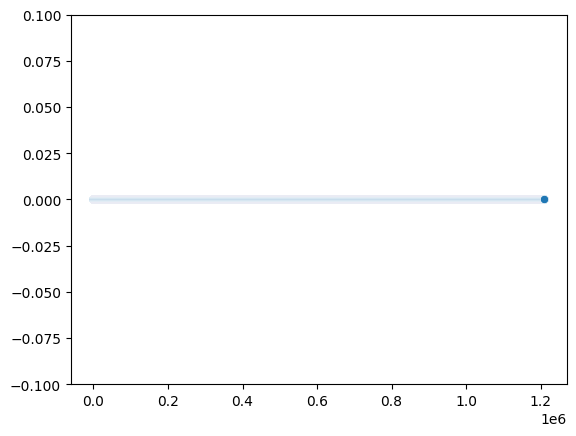

In [20]:
sns.scatterplot(y = spring[network.outlets[0]], x= t)
plt.ylim(-0.1, 0.1)

In [21]:
init_Q = Q[len(t) - 1]
init_h = y[len(t) - 1]


(<matplotlib.collections.LineCollection at 0x1d08c90e8d0>, None)

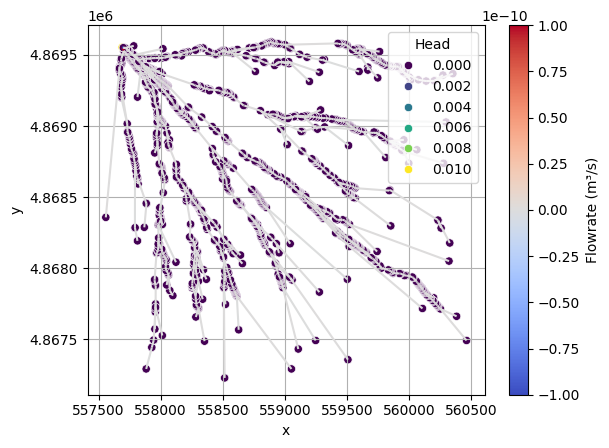

In [22]:
network.plot_network_flow(Q = init_Q, h = init_h)

In [17]:
network.plot_3D_network(node_color = 'd')

In [67]:
init_cond = {'initial_flowrate' : init_Q, 'initial_water_depth' : init_h}
write_pickle(f"conduit_geometry_test/input_data/init_conditions/{scenario}/{network_name}_IC.pkl", init_cond)

# Load Transient Results

In [61]:
run_name = 'd_0.1m/pykasso_n58_point'
results_dir = f'conduit_geometry_test/output/{run_name}/results_arrays.npz'
network_dir = f'conduit_geometry_test/networks/pykasso_n58'
network1 = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)

Q1, y1, t1, spring1 = get_transient_results(results_dir, network_dir)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58]


In [62]:
run_name = 'd_0.1m/straight_conduit_n62_point'
results_dir = f'conduit_geometry_test/output/{run_name}/results_arrays.npz'
network_dir = f'conduit_geometry_test/networks/straight_conduit_n62'
network2 = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)

Q2, y2, t2, spring2 = get_transient_results(results_dir, network_dir)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


In [84]:
temp = network2.nodes[network2.nodes.type != 'junction'][['x', 'y', 'z']].diff()
(temp.x**2 + temp.y**2 + temp.z**2)**.5

0            NaN
1    2329.691854
dtype: float64

In [63]:
run_name = 'd_0.1m/branching_straight_network_point'
results_dir = f'conduit_geometry_test/output/{run_name}/results_arrays.npz'
network_dir = f'conduit_geometry_test/networks/branching_straight_network'
network3 = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)
Q3, y3, t3, spring3 = get_transient_results(results_dir, network_dir)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]


Text(0, 0.5, 'Z (m)')

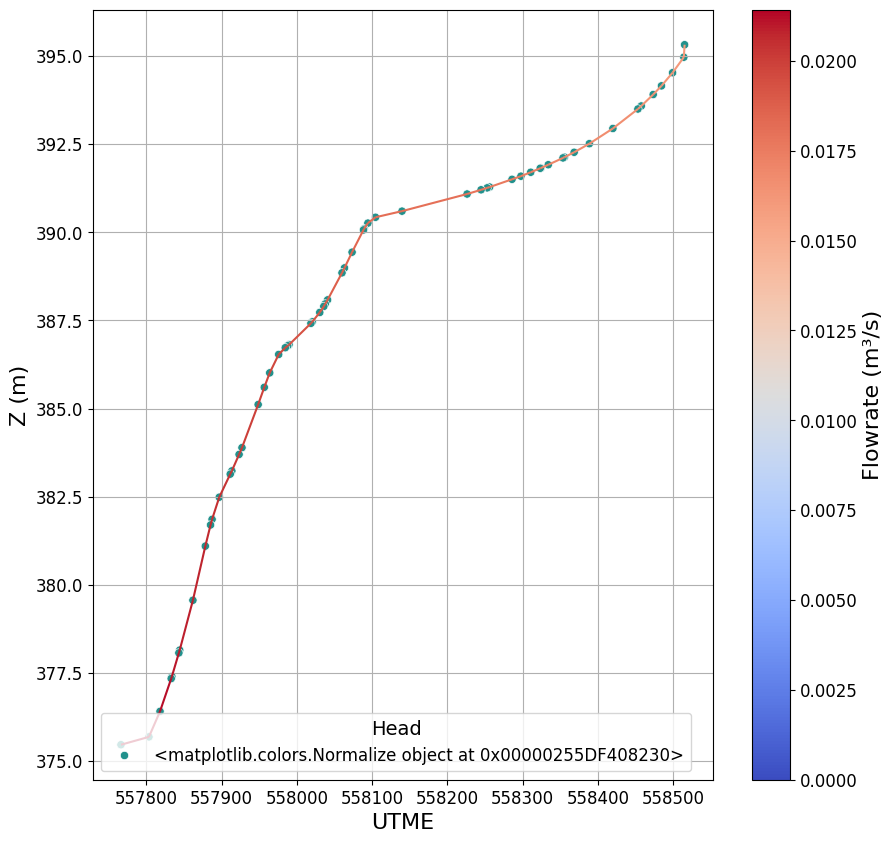

In [138]:
fig ,ax = plt.subplots( figsize = (10,10))
network1.plot_network_flow(Q1[-1], y1[-1], axes = ("x", "z"), ax =ax, vmin_q = 0, vmax_h = 0.2 )
plt.xlabel("UTME")
plt.ylabel("Z (m)")

Text(0, 0.5, 'Z (m)')

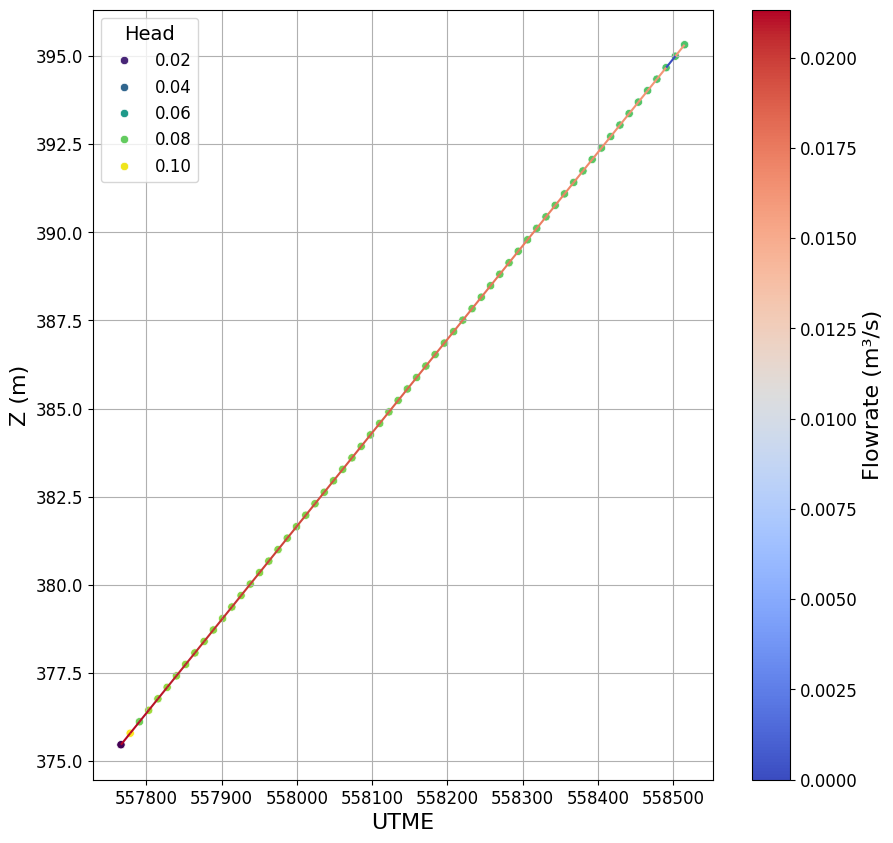

In [131]:
fig ,ax = plt.subplots( figsize = (10,10))
network2.plot_network_flow(Q2[-2], y2[-2], axes = ("x", "z"), ax = ax, vmin_q = 0,vmax_h = 0.2 )
plt.xlabel("UTME")
plt.ylabel("Z (m)")

Text(0, 0.5, 'Z (m)')

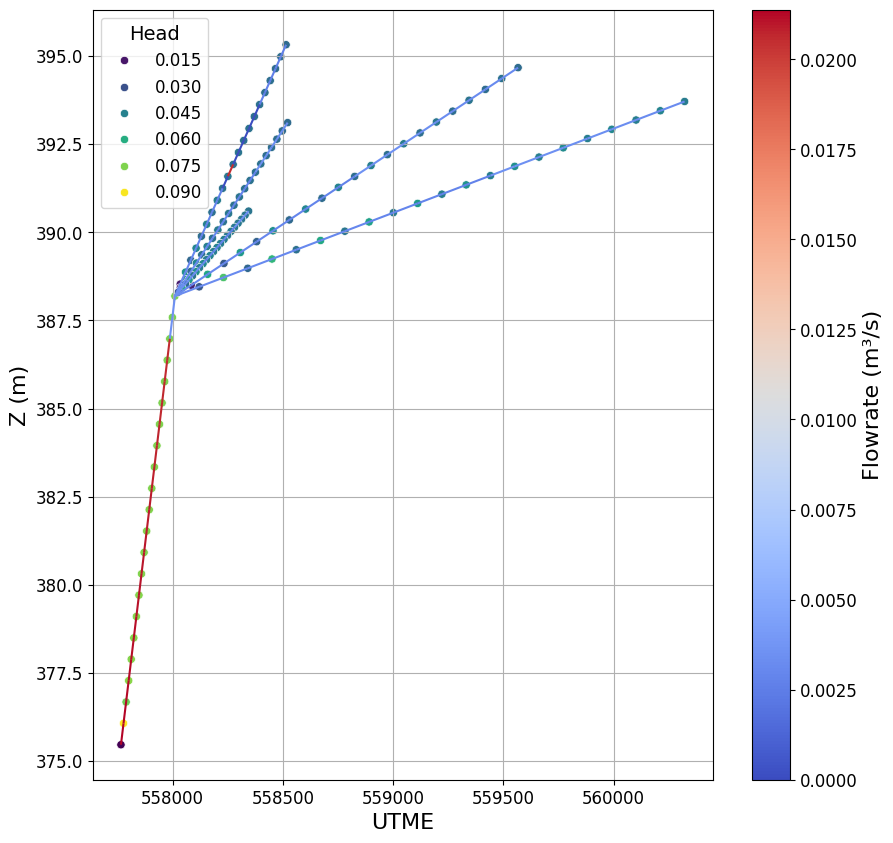

In [129]:
fig ,ax = plt.subplots( figsize = (10,10))
network3.plot_network_flow(Q3[-1], y3[-1], axes = ("x", "z"), ax = ax, vmin_q = 0)
plt.xlabel("UTME")
plt.ylabel("Z (m)")

In [64]:
data = {
        'Straight' : {'Q' : Q2, 't' : t2, 'h' : y2, 'spring' : spring2},

    'Tortuous' : {'Q' : Q1, 't' : t1, 'h' :y1, 'spring' : spring1},
    'Branching' : {'Q' : Q3, 't' : t3, 'h' : y3, 'spring' : spring3}
}
base_case = data['Straight']['spring'][list(data['Straight']['spring'].keys())[0]]

(1.0, 27.0)

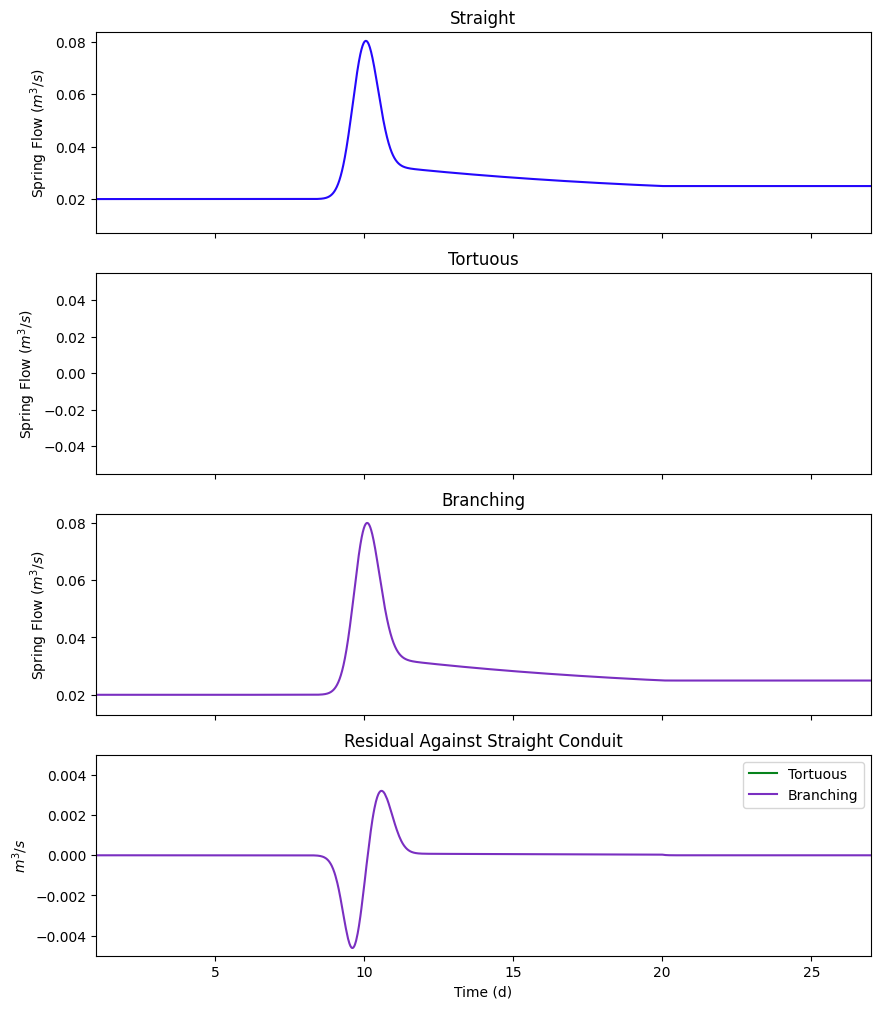

In [65]:
colors =     {'Straight':     "#2408FC",  
               # pastel coral/red
    'Tortuous':     "#07831C",
    'Branching' : "#7A2FC1"} # pastel purple
fig, ax = plt.subplots(len(data.keys())+1, 1, sharex = True, gridspec_kw={'wspace' : 0}, figsize = (10, 12))
i = 0
for name in data.keys():
    spring = data[name]['spring']
    t = data[name]['t']
    for node, Q_spring in spring.items():
        sns.lineplot(x = t/86400, y = Q_spring, color = colors[name], ax = ax[i])
        ax[i].set_title(name)
        # ax[i].set_ylim(0, 0.1)
        ax[i].set_ylabel(r"Spring Flow ($m^3/s$)")
        ax[i].set_xlim(1, 27)
        i+= 1
        if name != 'Straight': #plot residual against base case for non-straight cases
            sns.lineplot( x = t/86400, y = Q_spring - base_case, ax = ax[len(data.keys())], label = f"{name}", color = colors[name])
ax[len(data.keys())].set_xlabel("Time (d)")
ax[len(data.keys())].set_title("Residual Against Straight Conduit")
ax[len(data.keys())].set_ylabel(r"$m^3/s$")
ax[len(data.keys())].set_ylim(-0.005, 0.005)
ax[len(data.keys())].set_xlim(1, 27)


# ax[3].set_xlabel("Time (d)")
# ax[1].set_ylabel("Spring Flow (m3/s)")
# ax[0].set_title("Spring Discharge")
# sns.lineplot(x = sc_t/86400, y=pk_spring[pk_network.outlets[0]]-sc_spring[sc_network.outlets[0]], ax = ax[3], label = 'Tortuous')
# sns.lineplot(x = sc_t/86400, y=b_spring[b_network.outlets[0]]-sc_spring[sc_network.outlets[0]], ax = ax[3], label = 'Branching')
# ax[3].set_title("Residual Against Base Case")
# # for nodes, r_i in r.items():
# #     sns.lineplot(x = r_i['time'], y = r_i['flow'] * len(nodes), label = 'diffuse R' if len(nodes) > 1 else 'point R')
# plt.tight_layout()

<Axes: >

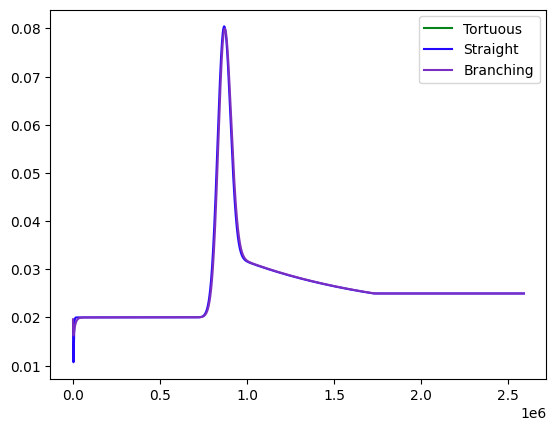

In [74]:
sns.lineplot(x = t1, y =spring1[58], label = 'Tortuous', color = colors['Tortuous'])
sns.lineplot(x = t2, y = spring2[1], label = 'Straight', color = colors['Straight'])
sns.lineplot(x = t3, y = spring3[6], label = 'Branching', color = colors['Branching'])

## Compare Recharge Conditions

In [85]:
network_name = 'slope_0008'

In [86]:
run_name = f'{network_name}/diffuse_only'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/input_files/{run_name}.yaml')
network = ok.load_network_data(f'conduit_geometry_test/networks/{network_name}/nodes.csv', f'conduit_geometry_test/networks/{network_name}/edges.csv')
network.extract_diffuse_inlets()
Q1 = results['Q']
y1 = results['y']
t1 = results['t']
spring1 = get_outlet_Q(Q1, network.outlets, network.edges)



In [87]:
run_name = f'{network_name}_gauss'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/input_files/{run_name}.yaml')
run_network = input['network_dir']
network = ok.load_network_data(f'conduit_geometry_test/{run_network}/nodes.csv', f'conduit_geometry_test/{run_network}/edges.csv')
network.extract_diffuse_inlets()
r = load_pickle(f'conduit_geometry_test/{input['inflow_file']}')
Q = results['Q']
y = results['y']
t = results['t']
spring = get_outlet_Q(Q, network.outlets, network.edges)

FileNotFoundError: [Errno 2] No such file or directory: 'conduit_geometry_test/output/slope_0008_gauss/results_arrays.npz'

In [88]:
run_name = f'{network_name}/point_only'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/input_files/{run_name}.yaml')
network = ok.load_network_data(f'conduit_geometry_test/networks/{network_name}/nodes.csv', f'conduit_geometry_test/networks/{network_name}/edges.csv')
network.extract_diffuse_inlets()
Q2 = results['Q']
y2= results['y']
t2 = results['t']
spring2 = get_outlet_Q(Q2, network.outlets, network.edges)

In [89]:
data = {
        'Point' : {'Q' : Q2, 't' : t2, 'h' : y2, 'spring' : spring2},

    'Diffuse' : {'Q' : Q1, 't' : t1, 'h' :y1, 'spring' : spring1},
}

In [96]:
t

array([1.00000e+01, 2.00000e+01, 3.00000e+01, ..., 1.47598e+06,
       1.47599e+06, 1.47600e+06])

(1.0, 27.0)

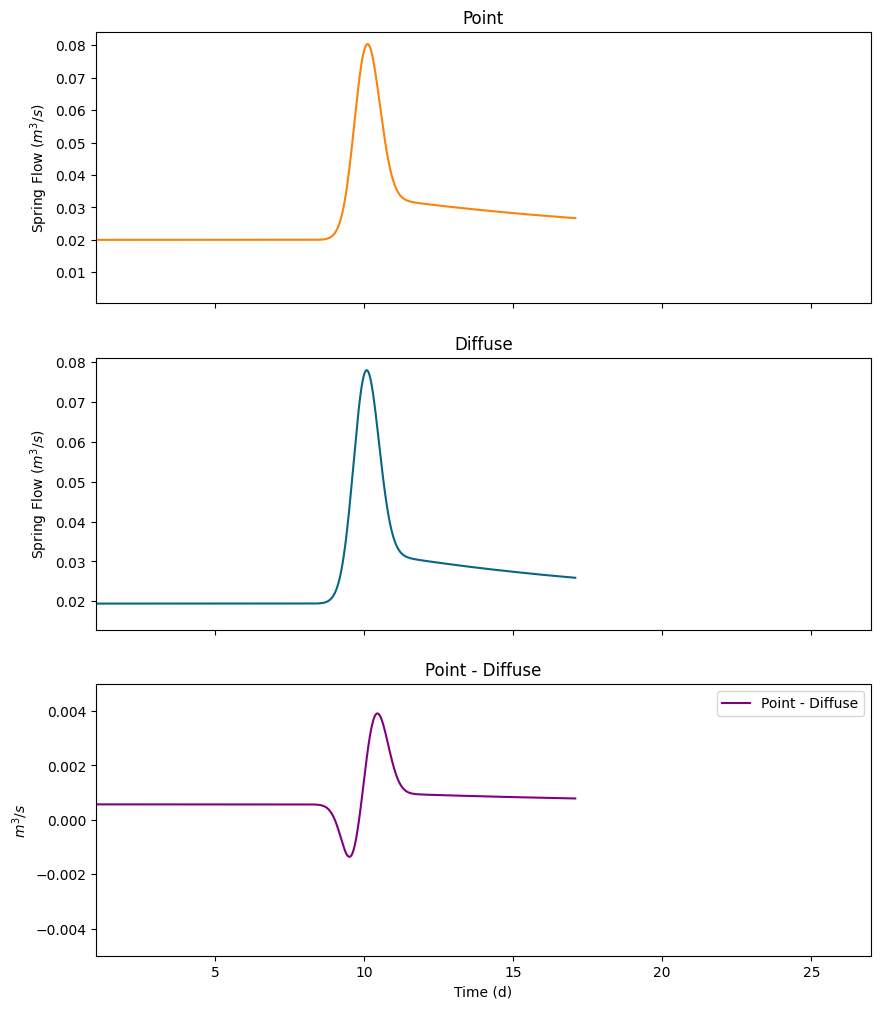

In [90]:
colors =     {'Point':     "#FC8208",  
               # pastel coral/red
    'Diffuse':     "#076683",
}
fig, ax = plt.subplots(len(data.keys())+1, 1, sharex = True, gridspec_kw={'wspace' : 0}, figsize = (10, 12))
i = 0
for name in data.keys():
    spring = data[name]['spring']
    t = data[name]['t']
    for node, Q_spring in spring.items():
        sns.lineplot(x = t/86400, y = Q_spring, color = colors[name], ax = ax[i])
        ax[i].set_title(name)
        # ax[i].set_ylim(0, 0.1)
        ax[i].set_ylabel(r"Spring Flow ($m^3/s$)")
        ax[i].set_xlim(1, 27)
        i+= 1
        # if name != 'Straight': #plot residual against base case for non-straight cases
sns.lineplot( x = t/86400, y = spring2[network.outlets[0]] - spring1[network.outlets[0]], ax = ax[len(data.keys())], label = f"Point - Diffuse", color = 'purple')
ax[len(data.keys())].set_xlabel("Time (d)")
ax[len(data.keys())].set_title("Point - Diffuse")
ax[len(data.keys())].set_ylabel(r"$m^3/s$")
ax[len(data.keys())].set_ylim(-0.005, 0.005)
ax[len(data.keys())].set_xlim(1, 27)


Text(0, 0.5, 'Spring Flow ($m^3/s$)')

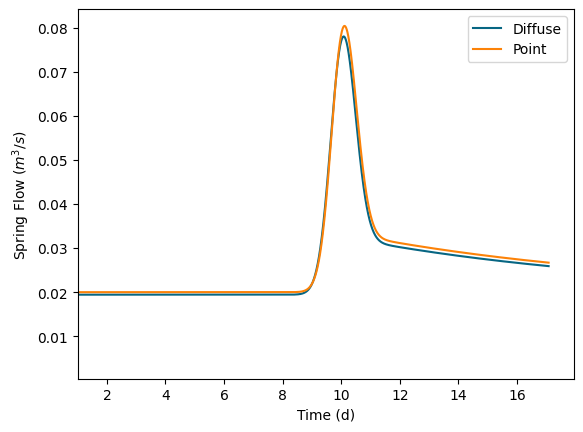

In [98]:
sns.lineplot(x = t1/86400, y =spring1[network.outlets[0]], label = 'Diffuse', color = colors['Diffuse'])
sns.lineplot(x = t2/86400, y = spring2[network.outlets[0]], label = 'Point', color = colors['Point'])
plt.xlabel("Time (d)")
plt.xlim(1,)
plt.ylabel(r"Spring Flow ($m^3/s$)")

# Conduit Network Volume 

In [137]:
network_name = 'high_eta/branching_straight_network_diffuse'
run_name = f'{network_name}'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/input_files/{run_name}.yaml')
run_network = input['network_dir']
network = ok.load_network_data(f'conduit_geometry_test/{run_network}/nodes.csv', f'conduit_geometry_test/{run_network}/edges.csv')
network.extract_diffuse_inlets()
r = load_pickle(f'conduit_geometry_test/{input['inflow_file']}')

In [138]:
network.calculate_network_volume()

np.float64(6360.798072268418)